# Car Price Prediction

### Business Objective

A Chinese automobile company plans to enter the US automobile market and manufacture cars locally. The objective of this project is to identify the factors that significantly influence car prices in the American market and to build machine learning regression models that can predict car prices.

### Project Objectives

1. Load and preprocess the automobile dataset.
2. Implement five regression algorithms:
   - Linear Regression
   - Decision Tree Regressor
   - Random Forest Regressor
   - Gradient Boosting Regressor
   - Support Vector Regressor
3. Evaluate and compare the models using:
   - R-squared (R²)
   - Mean Squared Error (MSE)
   - Mean Absolute Error (MAE)
4. Identify the important features affecting car prices.
5. Perform hyperparameter tuning and compare the tuned model with the original model.
6. Draw business-oriented conclusions from the analysis.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset

df = pd.read_csv("CarPrice_Assignment.csv")

print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)

df.head()

Dataset loaded successfully.
Shape of the dataset: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [3]:
# Inspect dataset information

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    

## Data Preprocessing

The dataset contains 205 records and 26 columns. There are no missing values or duplicate records.

The `car_ID` column is an identifier and does not provide useful information for predicting price, so it will be removed.

The `CarName` column contains the complete car name. Instead of treating every individual car name as a separate category, the automobile brand is extracted from the first part of the car name. This provides a more useful categorical feature for the pricing model.

In [4]:
# Preprocess the dataset

# Extract car brand from CarName
df["brand"] = df["CarName"].str.split().str[0].str.lower()

# Remove identifier and original car name
df = df.drop(columns=["car_ID", "CarName"])

# Separate features and target variable
X = df.drop(columns=["price"])
y = df["price"]

print("Preprocessing completed successfully.")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Preprocessing completed successfully.
Feature shape: (205, 24)
Target shape: (205,)

Features:
['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'brand']

Target variable:
price


## Feature Identification and Train-Test Split

The predictor variables are divided into numerical and categorical features based on their data types. The target variable is `price`.

The dataset is divided into training and testing sets so that the models can be trained on one portion of the data and evaluated on unseen data.

In [5]:
# Identify numerical and categorical features

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

Categorical features:
['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']


In [6]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (164, 24)
Testing data shape: (41, 24)
Training target shape: (164,)
Testing target shape: (41,)


## Encoding and Scaling

Machine learning regression algorithms require numerical input. Therefore, categorical variables are converted into numerical form using One-Hot Encoding.

Numerical variables are standardized using StandardScaler. The preprocessing is implemented inside a pipeline to ensure that transformations are learned only from the training data and applied consistently to the test data.

In [7]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Regression Model Implementation

Five regression algorithms specified in the assessment are implemented:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. Support Vector Regressor

In [8]:
# Define the five regression models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "Support Vector Regressor": SVR()
}

print("Five regression models created successfully.")

Five regression models created successfully.


In [9]:
# Train and evaluate all five models

results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2": r2,
        "MSE": mse,
        "MAE": mae
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

print("Model training and evaluation completed.")

results_df.sort_values(by="R2", ascending=False)

Model training and evaluation completed.


,Model,R2,MSE,MAE
2,Random Forest,0.957759,3.334668e+06,1287.184921
3,Gradient Boosting,0.928890,5.613676e+06,1678.434859
1,Decision Tree,0.913599,6.820817e+06,1704.142268
0,Linear Regression,0.899843,7.906808e+06,1835.328036
4,Support Vector Regressor,-0.099790,8.682185e+07,5695.273987


## Model Performance Comparison

The performance of the five regression models is compared using R², MSE, and MAE.

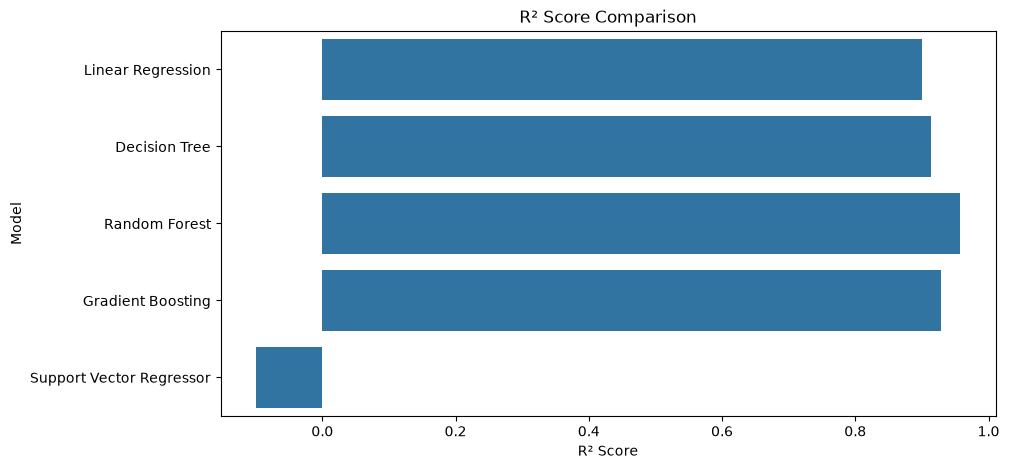

In [10]:
# Plot R2 comparison

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.title("R² Score Comparison")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.show()

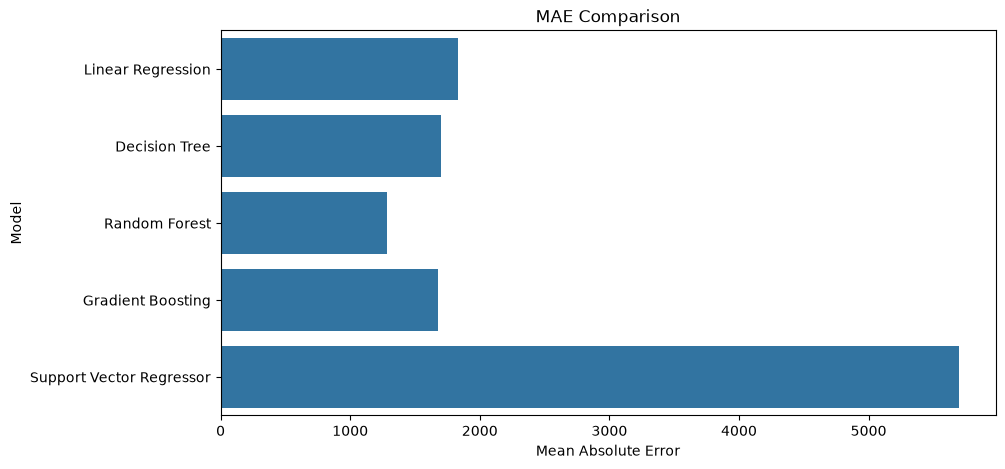

In [11]:
# Plot MAE comparison

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)

plt.title("MAE Comparison")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Model")
plt.show()

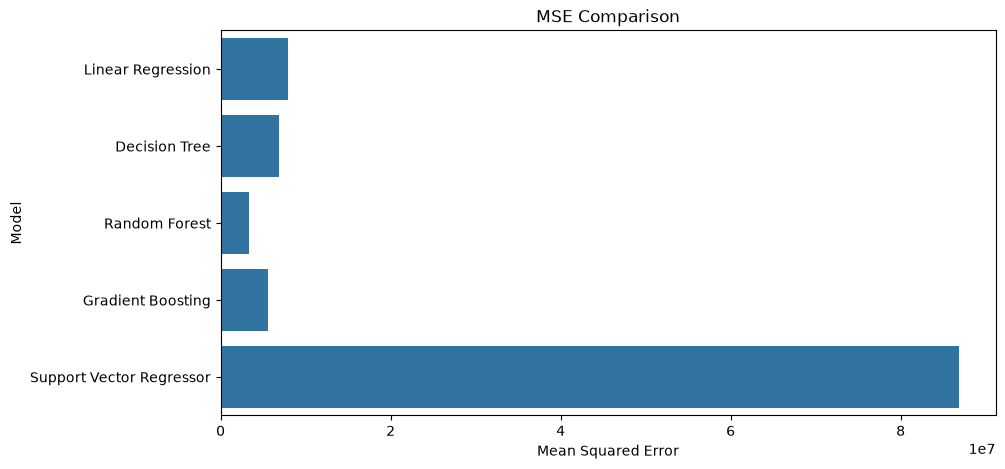

In [12]:
# Plot MSE comparison

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="MSE",
    y="Model"
)

plt.title("MSE Comparison")
plt.xlabel("Mean Squared Error")
plt.ylabel("Model")
plt.show()

In [13]:
# Identify the best-performing model based on R2

best_model_name = results_df.loc[
    results_df["R2"].idxmax(), "Model"
]

best_r2 = results_df["R2"].max()

print("Best-performing model based on R²:", best_model_name)
print("Best R² score:", round(best_r2, 4))

Best-performing model based on R²: Random Forest
Best R² score: 0.9578


## Feature Importance Analysis

Feature importance is analyzed using the Random Forest Regressor. The importance values indicate how much each transformed feature contributes to the model's prediction of car prices.

Higher importance values indicate features that the Random Forest relied on more heavily when making predictions.

In [14]:
# Extract feature importance from the Random Forest model

rf_pipeline = trained_models["Random Forest"]

# Get transformed feature names
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get importance values
importance_values = rf_pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 important features:")
feature_importance.head(15)

Top 15 important features:


,Feature,Importance
6,num__enginesize,0.575433
5,num__curbweight,0.271665
13,num__highwaympg,0.044571
10,num__horsepower,0.026734
3,num__carwidth,0.012659
2,num__carlength,0.008565
53,cat__brand_bmw,0.007164
1,num__wheelbase,0.007154
12,num__citympg,0.006675
11,num__peakrpm,0.005398


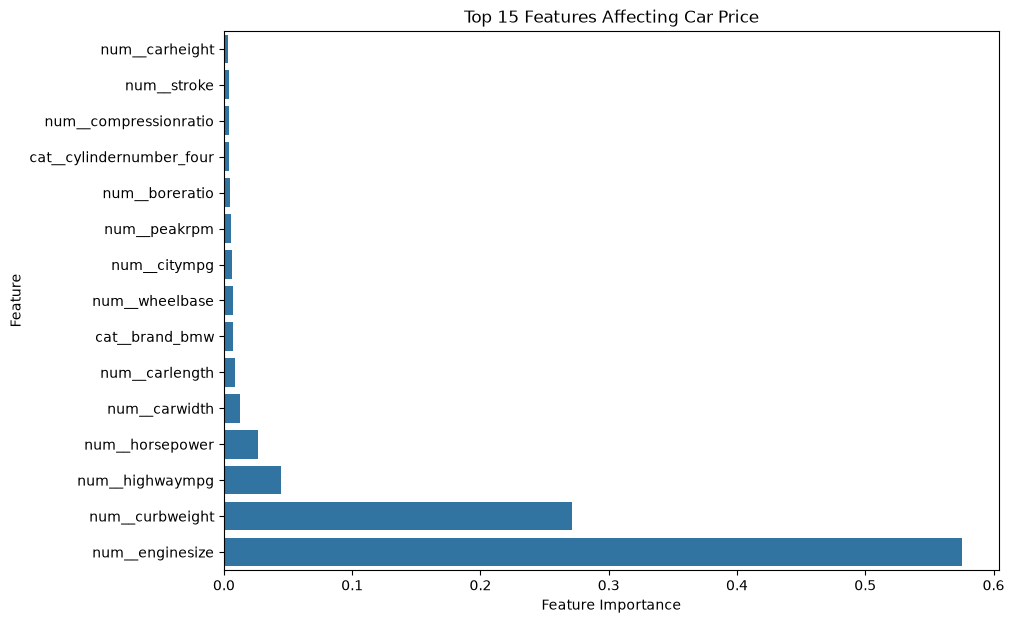

In [15]:
# Visualize the top 15 important features

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Affecting Car Price")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [16]:
# Display the top 10 important features

print("Top 10 important features affecting car price:\n")

for i, row in feature_importance.head(10).reset_index(drop=True).iterrows():
    print(
        f"{i + 1}. {row['Feature']} - "
        f"{row['Importance']:.4f}"
    )

Top 10 important features affecting car price:

1. num__enginesize - 0.5754
2. num__curbweight - 0.2717
3. num__highwaympg - 0.0446
4. num__horsepower - 0.0267
5. num__carwidth - 0.0127
6. num__carlength - 0.0086
7. cat__brand_bmw - 0.0072
8. num__wheelbase - 0.0072
9. num__citympg - 0.0067
10. num__peakrpm - 0.0054


## Hyperparameter Tuning

The Random Forest Regressor achieved the highest R² score among the five baseline models. Therefore, GridSearchCV is used to search for a better combination of Random Forest hyperparameters.

The tuned model is evaluated on the same unseen test set and compared with the original Random Forest model.

In [17]:
# Define the parameter grid for Random Forest

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

print("Hyperparameter grid created.")

Hyperparameter grid created.


In [18]:
# Hyperparameter tuning using GridSearchCV

rf_pipeline_tuning = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(
    estimator=rf_pipeline_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Hyperparameter tuning completed.")
print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation R²:")
print(round(grid_search.best_score_, 4))

Hyperparameter tuning completed.

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best cross-validation R²:
0.8894


In [19]:
# Evaluate the tuned Random Forest on the test data

tuned_rf = grid_search.best_estimator_

y_pred_tuned = tuned_rf.predict(X_test)

tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_mse = mean_squared_error(y_test, y_pred_tuned)
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("R² :", round(tuned_r2, 4))
print("MSE:", round(tuned_mse, 2))
print("MAE:", round(tuned_mae, 2))

Tuned Random Forest Performance
--------------------------------
R² : 0.9566
MSE: 3429185.99
MAE: 1308.44


In [20]:
# Compare baseline and tuned Random Forest

comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "R2": [
        results_df.loc[
            results_df["Model"] == "Random Forest", "R2"
        ].iloc[0],
        tuned_r2
    ],
    "MSE": [
        results_df.loc[
            results_df["Model"] == "Random Forest", "MSE"
        ].iloc[0],
        tuned_mse
    ],
    "MAE": [
        results_df.loc[
            results_df["Model"] == "Random Forest", "MAE"
        ].iloc[0],
        tuned_mae
    ]
})

comparison

,Model,R2,MSE,MAE
0,Baseline Random Forest,0.957759,3.334668e+06,1287.184921
1,Tuned Random Forest,0.956562,3.429186e+06,1308.435297


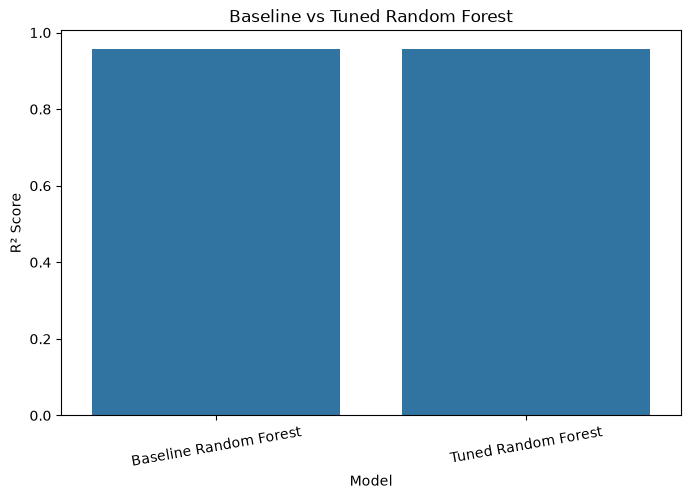

In [21]:
# Compare baseline and tuned Random Forest R²

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2"
)

plt.title("Baseline vs Tuned Random Forest")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=10)

plt.show()

## Hyperparameter Tuning Results

GridSearchCV was used to tune the Random Forest Regressor using 5-fold cross-validation.

The best parameters obtained were:

- Number of estimators: 100
- Maximum depth: None
- Minimum samples split: 2
- Minimum samples leaf: 1

The baseline Random Forest achieved an R² of 0.9578 on the test set, while the tuned model achieved an R² of 0.9566.

The baseline model also produced slightly lower MSE and MAE than the tuned model. Therefore, hyperparameter tuning did not improve the test-set performance in this particular experiment.

This result demonstrates that tuning does not always lead to an improvement in performance, and model performance should be evaluated using unseen test data.

## Actual vs Predicted Car Prices

The actual car prices are compared with the prices predicted by the Random Forest model. Points closer to the diagonal relationship indicate more accurate predictions.

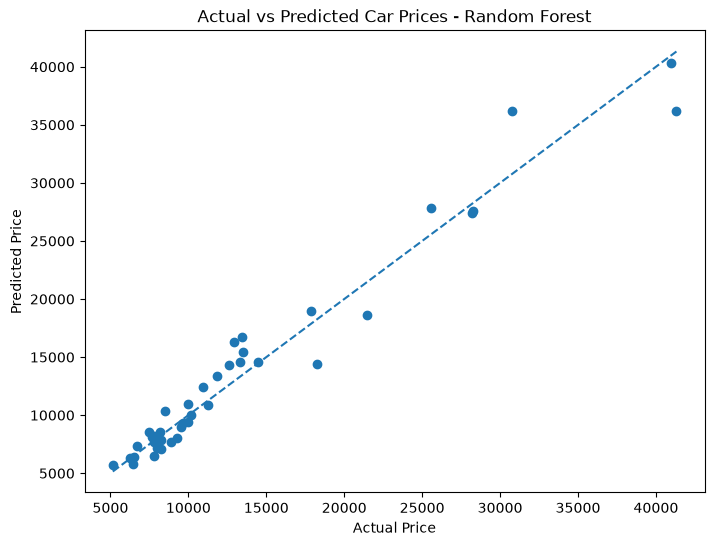

In [22]:
# Actual vs Predicted prices for Random Forest

rf_model = trained_models["Random Forest"]

y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices - Random Forest")

# Reference line
min_price = min(y_test.min(), y_pred_rf.min())
max_price = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.show()

## Residual Analysis

Residuals represent the difference between the actual and predicted prices. A residual analysis helps identify whether the model's prediction errors show any noticeable pattern.

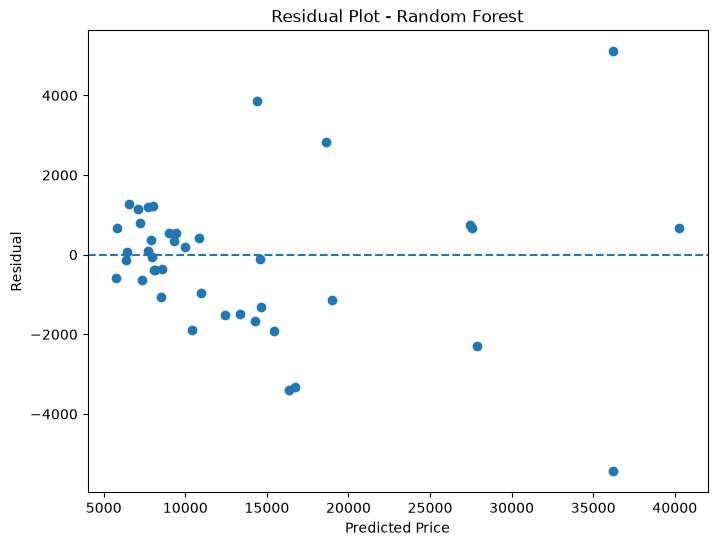

In [23]:
# Calculate residuals

residuals = y_test - y_pred_rf

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_rf, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot - Random Forest")

plt.show()

## Business Insights

The Random Forest feature importance analysis shows that engine size and curb weight are the two most influential features in the model.

Engine size has the highest importance value of approximately 0.5754, followed by curb weight with an importance of approximately 0.2717. Highway MPG and horsepower are also among the more influential variables.

These findings suggest that vehicle engineering and physical characteristics play an important role in the model's prediction of automobile prices. The company can use these insights when studying vehicle design, product positioning, and pricing strategies for the US market.

The feature importance values represent the contribution of variables to the Random Forest model and should not be interpreted as proof of a causal relationship or statistical significance.

## Conclusion

This project developed machine learning regression models to predict automobile prices using vehicle specifications and characteristics.

Five regression algorithms were implemented: Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and Support Vector Regressor.

Among the five baseline models, the Random Forest Regressor achieved the highest test-set R² score of 0.9578. It also achieved the lowest MSE and MAE among the models evaluated, with an MSE of approximately 3,334,668 and an MAE of approximately 1,287.

Feature importance analysis showed that engine size was the most influential feature in the Random Forest model, followed by curb weight. Highway MPG and horsepower were also among the relatively important features.

Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation. The tuned Random Forest achieved an R² of 0.9566 on the test set, which was slightly lower than the baseline model's R² of 0.9578. Therefore, tuning did not improve the test-set performance in this experiment.

The analysis provides useful insights into the vehicle characteristics associated with automobile price predictions. These findings can support the automobile company's understanding of pricing patterns and assist in studying vehicle design and pricing strategies for entering the US market.